# 07 — Explainable ML: EBM + GBM + SHAP + ALE (§4B)
**Kernel: `Python (pf_ml)`.** LightGBM (robust with SHAP) + glass-box EBM predict the 40-dBZ top from the environment; **SHAP** ranks drivers, shows the shear functional form, and the **CAPE×shear interaction**; **ALE** gives the correlation-robust shear effect. For a GPU run on `l40s`, CatBoost `task_type='GPU'` or XGBoost `device='cuda'` (note: pin a SHAP/XGBoost pair that parse together — LightGBM is used here for SHAP reliability).

In [1]:
import sys; sys.path.insert(0,'.')
import numpy as np, warnings; warnings.filterwarnings('ignore')
from functools import reduce
from _shc import *
con = connect()
# Predictors: ambient CAPE + CIN + moisture + SKIN TEMP (skt; defined over land&ocean,
# unlike SST) + 3 shear layers + |lat|.  Treatment = 0-6 km shear.
PREDICTORS = [AMBIENT_CAPE, CIN, MOISTURE, 'mean_skt_2p50deg',
              'shear_1000m_centroid','shear_3000m_centroid','shear_6000m_centroid','abs_lat']
TREATMENT  = SHEAR
RESPONSES  = ['ht40_km','ht30_km','ht20_km','min_pct_85_89','min_pct_37']
# max_ht_40dbz is NULL when no 40-dBZ echo exists -> for echo-top HEIGHT models we sample the
# deep subset (finite ht40); CIN is occasionally NULL -> impute 0 (no inhibition).

import lightgbm as lgb, shap
from sklearn.model_selection import train_test_split
df = load_sample(con, ['ht40_km']+PREDICTORS, mission='TRMM', n=200_000, where='AND ht40_km IS NOT NULL')
df[CIN] = df[CIN].fillna(0.0); df = df.dropna(subset=PREDICTORS+['ht40_km'])
X, y = df[PREDICTORS], df['ht40_km']
Xtr,Xte,ytr,yte = train_test_split(X, y, test_size=.25, random_state=0)
print('deep sample:', df.shape)

deep sample: (200000, 9)


### LightGBM + TreeSHAP — ranked drivers, shear functional form, CAPE×shear interaction

test R^2 = 0.309


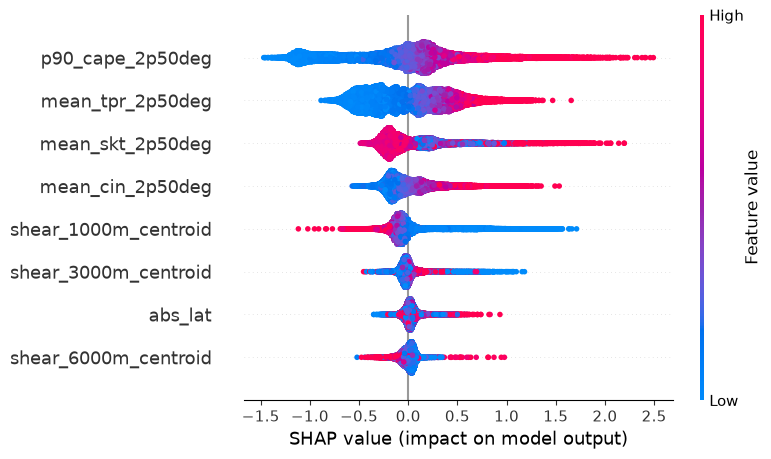

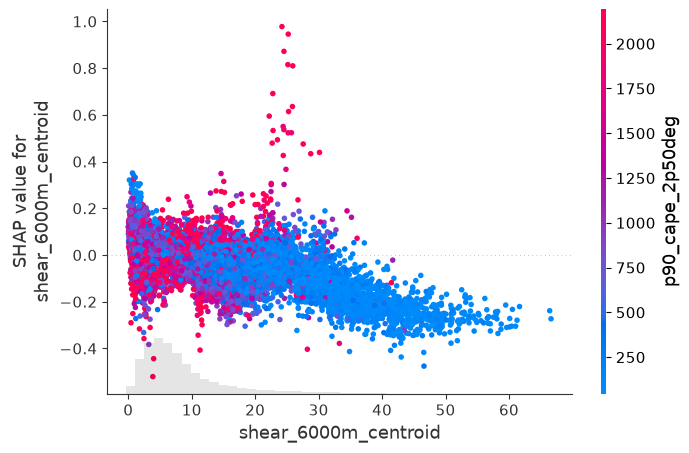

In [2]:
m = lgb.LGBMRegressor(n_estimators=500, learning_rate=.05, num_leaves=63, verbose=-1).fit(Xtr, ytr)
print('test R^2 =', round(m.score(Xte, yte), 3))
expl = shap.TreeExplainer(m); sv = expl(Xte)
shap.summary_plot(sv, Xte, show=True)
shap.plots.scatter(sv[:, 'shear_6000m_centroid'], color=sv[:, AMBIENT_CAPE], show=True)

### SHAP interaction strength: CAPE×shear vs all pairs

In [3]:
iv = expl.shap_interaction_values(Xte.sample(min(3000,len(Xte)), random_state=0))
names = list(Xte.columns); M = np.abs(iv).mean(0); np.fill_diagonal(M, 0)
i,j = names.index('shear_6000m_centroid'), names.index(AMBIENT_CAPE)
rank = int((M[np.triu_indices_from(M,1)] > M[i,j]).sum()) + 1
print(f'mean|SHAP interaction| CAPE x shear = {M[i,j]:.4f}  (rank {rank} of all pairs)')

mean|SHAP interaction| CAPE x shear = 0.0104  (rank 24 of all pairs)


### Glass-box EBM term importances

In [4]:
from interpret.glassbox import ExplainableBoostingRegressor
ebm = ExplainableBoostingRegressor(interactions=10).fit(Xtr, ytr)
for nm,v in sorted(zip(ebm.term_names_, ebm.term_importances()), key=lambda t:-t[1])[:12]:
    print(f'  {v:7.3f}  {nm}')

    0.443  p90_cape_2p50deg
    0.393  mean_tpr_2p50deg
    0.319  mean_skt_2p50deg
    0.224  mean_cin_2p50deg
    0.154  shear_1000m_centroid
    0.114  shear_6000m_centroid
    0.091  shear_3000m_centroid
    0.082  mean_skt_2p50deg & abs_lat
    0.078  p90_cape_2p50deg & mean_skt_2p50deg
    0.074  p90_cape_2p50deg & mean_cin_2p50deg
    0.046  abs_lat
    0.037  mean_cin_2p50deg & mean_skt_2p50deg


### ALE — correlation-robust effect of shear

PyALE._ALE_generic:INFO: Continuous feature detected.


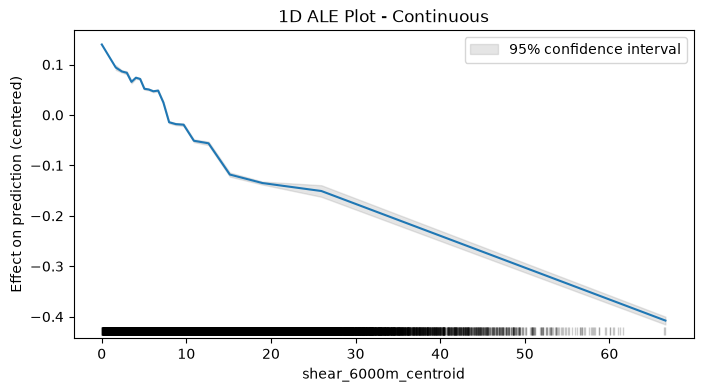

In [5]:
from PyALE import ale
_ = ale(X=Xte, model=m, feature=['shear_6000m_centroid'], grid_size=20, include_CI=True)
plt.show()